In [196]:
from scipy.integrate import quad
import numpy as np

t0 = 77.97
while t0 < 77.98:
    t0 += 0.00005
    vp = 3660
    dmdt = 15
    gl = -1.62
    M = 2150
    mass = 150
    V0y=47
    H0 = 1400
    
    def m(t):
        res = M + mass
        if t<=t0:
            return res
        else:
            return res - dmdt*(t-t0)
    
    def a(t):
        if t<=t0:
            return gl
        else:
            return gl + vp*dmdt/m(t)
    
    def V(t):
        if t<=t0:
            return V0y + gl*t
        else:
            result, error = quad(a, t0, t)
            return V(t0) + result
            
    def H(t):
        if t<=t0:
            return H0 + V0y*t + gl*t*t/2
        else:
            result, error = quad(V, t0, t)
            return H(t0) + result
    
    
    x = np.linspace(t0-10, t0+10, 20000)
    
    speed = [V(i) for i in x]
    acceleration = [a(i) for i in x]
    height = [H(i) for i in x]
    
    index_t1 = 0
    for i in range(len(x)):
        if abs(height[i]) < abs(height[index_t1]):
            index_t1 = i
    
    #print(x[index_t1], "diff with thero: ", abs(height[index_t1]))
    #print(x[index_t1], "speed: ", speed[index_t1])
    #print(t0, "<", x[index_t1])
    if (t0 < x[index_t1]) and (speed[index_t1] <= 0) and (speed[index_t1] >= -3) and abs(height[index_t1]) <= 0.0001:
        print(x[index_t1], "diff with thero: ", abs(height[index_t1]))
        print(x[index_t1], "speed: ", speed[index_t1])
        print(t0, "<", x[index_t1])
        
        

print('end')

81.45462413370674 diff with thero:  7.156122705964663e-05
81.45462413370674 speed:  -0.8679618210200033
77.97195000000006 < 81.45462413370674
81.40742173358677 diff with thero:  4.0614581479303524e-05
81.40742173358677 speed:  -1.9637320247921792
77.97275000000009 < 81.40742173358677
81.39377103355179 diff with thero:  1.2955021333027616e-05
81.39377103355179 speed:  -2.2834499569753604
77.9731000000001 < 81.39377103355179
end


77.97317971279857
81.39377 diff with thero:  1.0594937805308291e-05
81.39377 speed:  -2.2834735159746202
140.08787541261768


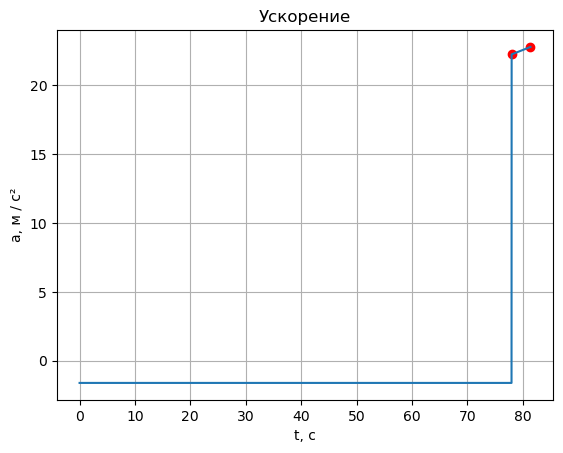

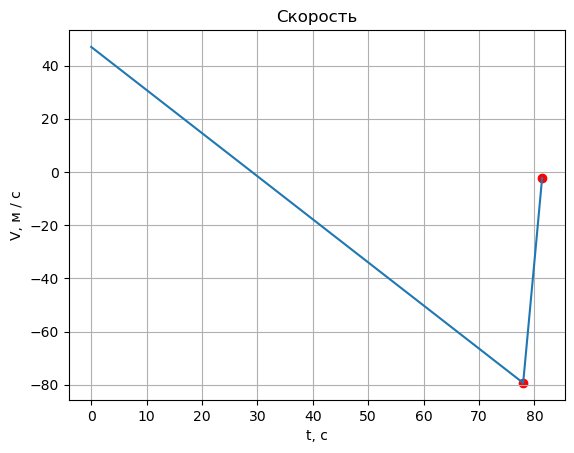

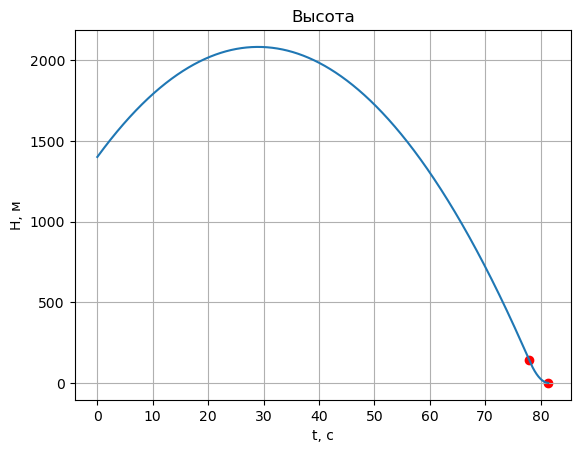

22.794215041073137


In [221]:
t0 = 77.9731
vp = 3660
dmdt = 15
gl = -1.62
M = 2150
mass = 150
V0y=47
H0 = 1400

def m(t):
    res = M + mass
    if t<=t0:
        return res
    else:
        return res - dmdt*(t-t0)

def a(t):
    if t<=t0:
        return gl
    else:
        return gl + vp*dmdt/m(t)

def V(t):
    if t<=t0:
        return V0y + gl*t
    else:
        result, error = quad(a, t0, t)
        return V(t0) + result
        
def H(t):
    if t<=t0:
        return H0 + V0y*t + gl*t*t/2
    else:
        result, error = quad(V, t0, t)
        return H(t0) + result


x = np.linspace(0, 81.39377, 200000)

speed = [V(i) for i in x]
acceleration = [a(i) for i in x]
height = [H(i) for i in x]

index_t1 = 0
for i in range(len(x)):
    if abs(height[i]) < abs(height[index_t1]):
        index_t1 = i
index_t0 = 0
for i in range(len(x)):
    if abs(x[i]-t0) < abs(x[index_t0]-t0):
        index_t0 = i
print(x[index_t0])

print(x[index_t1], "diff with thero: ", abs(height[index_t1]))
print(x[index_t1], "speed: ", speed[index_t1])
print(height[index_t0])

# Создаем график
graphic = acceleration
plt.plot(x, graphic)
plt.title('Ускорение')
plt.xlabel('t, с')
plt.ylabel('a, м / с²')
plt.scatter(x[index_t1], graphic[index_t1], color='red')
plt.scatter(x[index_t0], graphic[index_t0], color='red')
plt.grid(True)
plt.show()

graphic = speed
plt.plot(x, graphic)
plt.title('Скорость')
plt.xlabel('t, с')
plt.ylabel('V, м / с')
plt.scatter(x[index_t1], graphic[index_t1], color='red')
plt.scatter(x[index_t0], graphic[index_t0], color='red')
plt.grid(True)
plt.show()

graphic = height
plt.plot(x, graphic)
plt.title('Высота')
plt.xlabel('t, с')
plt.ylabel('H, м')
plt.scatter(x[index_t1], graphic[index_t1], color='red')
plt.scatter(x[index_t0], graphic[index_t0], color='red')
plt.grid(True)
plt.show()

print(acceleration[index_t1])